# Probabilistic Supply Chain Simulation
**Objective:** Compare a Deterministic supply chain model against a Probabilistic model where Demand, Supplier Lead Time, and Assembly Production Time are treated as independent Gaussian (Normal) distributions. 

The algorithm calculates the exact Safety Stock required to achieve a user-defined Service Level (certainty of fulfillment) based on the combined variance of all three stochastic variables.

In [34]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Set seed for reproducible research
np.random.seed(101)

# --- 1. Define the Gaussian Parameters ---
# D = Demand per week
mu_D = 100.0
var_D = 400.0  # std_dev = 20

# L = Supplier Lead Time (weeks)
mu_L = 2.0
var_L = 0.16   # std_dev = 0.5

# P = Assembly Production Time (weeks)
mu_P = 1.0
var_P = 0.04   # std_dev ~ 0.33

# Review Period (R = 1 week for standard MRP-like weekly buckets)
R = 1.0

# Costs
COST_HOLDING = 5      # Cost to hold 1 unit per week
COST_STOCKOUT = 100   # Penalty per unit short

## The Probabilistic Calculator
This function calculates the theoretical Safety Stock and Order-Up-To level required to meet the user's requested certainty (Service Level) using the inverse cumulative distribution function (Z-score).

In [35]:
def calculate_probabilistic_parameters(certainty_pct):
    """
    Calculates the required Order-Up-To Level and Safety Stock 
    based on the combined variance of Demand, Lead Time, and Production.
    
    Parameters:
    certainty_pct (float): Target service level (e.g., 0.95 for 95%)
    """
    # Get the Z-score for the requested certainty
    # If certainty is 0.50 (deterministic mean), Z is 0.
    z_score = stats.norm.ppf(certainty_pct)
    
    # 1. Total Vulnerable Time (T) = Review Period + Lead Time + Prod Time
    mu_T = R + mu_L + mu_P
    var_T = var_L + var_P # Variances of independent times add up
    
    # 2. Expected Demand during Vulnerable Time
    expected_demand_T = mu_T * mu_D
    
    # 3. Variance of Demand during Vulnerable Time
    # Formula combining variance of demand and variance of time
    var_demand_T = (mu_T * var_D) + ((mu_D ** 2) * var_T)
    std_dev_demand_T = np.sqrt(var_demand_T)
    
    # 4. Calculate Safety Stock
    safety_stock = z_score * std_dev_demand_T
    
    # 5. Calculate Order-Up-To Level
    order_up_to = expected_demand_T + safety_stock
    
    return {
        "Certainty": f"{certainty_pct*100}%",
        "Z-Score": round(z_score, 3),
        "Expected_Demand_T": round(expected_demand_T, 1),
        "Combined_Std_Dev": round(std_dev_demand_T, 1),
        "Safety_Stock": max(0, int(round(safety_stock))),
        "Order_Up_To_Level": int(round(order_up_to))
    }

# Display theoretical parameters for different targets
targets = [0.50, 0.90, 0.95, 0.99] # 50% represents the traditional deterministic mean
param_results = [calculate_probabilistic_parameters(t) for t in targets]
df_params = pd.DataFrame(param_results)
display(df_params)

,Certainty,Z-Score,Expected_Demand_T,Combined_Std_Dev,Safety_Stock,Order_Up_To_Level
0,50.0%,0.000,400.0,60.0,0,400
1,90.0%,1.282,400.0,60.0,77,477
2,95.0%,1.645,400.0,60.0,99,499
3,99.0%,2.326,400.0,60.0,140,540


## The Simulation Engine
We will now test these theoretical parameters in a week-by-week simulation where the actual demand and actual times are drawn from our defined Gaussian distributions.

In [36]:
def simulate_supply_chain(order_up_to_level, weeks=104):
    """
    Simulates the supply chain over a set number of weeks.
    Actual demand, lead time, and production time are drawn from normal distributions.
    """
    # State variables
    inventory = order_up_to_level # Start fully stocked
    scheduled_receipts = {}       # Dictionary to track incoming orders {arrival_week: quantity}
    
    # KPIs
    total_stockouts = 0
    total_holding_inventory = 0
    weeks_with_stockout = 0
    
    for current_week in range(weeks):
        # 1. Receive incoming orders
        if current_week in scheduled_receipts:
            inventory += scheduled_receipts[current_week]
            del scheduled_receipts[current_week] # Clear the receipt
            
        # 2. Realize Stochastic Demand for the week
        # Use max(0) to prevent impossible negative demand from the Gaussian draw
        actual_demand = max(0, int(np.random.normal(mu_D, np.sqrt(var_D))))
        
        # 3. Fulfill Demand & Calculate Stockouts
        if inventory >= actual_demand:
            inventory -= actual_demand
            total_holding_inventory += inventory
        else:
            total_stockouts += (actual_demand - inventory)
            weeks_with_stockout += 1
            inventory = 0 # Assume lost sales, not backordered
            
        # 4. Place New Order (Periodic Review / MRP logic)
        # Calculate pipeline inventory (orders already placed but not yet received)
        pipeline_inventory = sum(scheduled_receipts.values())
        inventory_position = inventory + pipeline_inventory
        
        order_qty = order_up_to_level - inventory_position
        
        if order_qty > 0:
            # 5. Realize Stochastic Lead Time & Production Time
            actual_L = max(0, np.random.normal(mu_L, np.sqrt(var_L)))
            actual_P = max(0, np.random.normal(mu_P, np.sqrt(var_P)))
            
            # Calculate when this order will actually arrive
            total_replenishment_time = int(round(actual_L + actual_P))
            arrival_week = current_week + total_replenishment_time + 1
            
            # Add to schedule
            if arrival_week in scheduled_receipts:
                scheduled_receipts[arrival_week] += order_qty
            else:
                scheduled_receipts[arrival_week] = order_qty

    # Calculate final metrics
    holding_cost = total_holding_inventory * COST_HOLDING
    stockout_cost = total_stockouts * COST_STOCKOUT
    actual_service_level = 1 - (weeks_with_stockout / weeks)
    
    return {
        "Actual_Service_Level": f"{actual_service_level*100:.1f}%",
        "Total_Stockouts": total_stockouts,
        "Holding_Cost": holding_cost,
        "Stockout_Cost": stockout_cost,
        "Total_Cost": holding_cost + stockout_cost
    }

## Execution & Comparison
We will run a 2-year (104 week) simulation for the Traditional Deterministic model (50% certainty) against our Probabilistic models.

In [37]:
# Extract the Order-Up-To levels calculated earlier
out_deterministic = df_params.loc[df_params['Certainty'] == '50.0%', 'Order_Up_To_Level'].values[0]
out_90 = df_params.loc[df_params['Certainty'] == '90.0%', 'Order_Up_To_Level'].values[0]
out_95 = df_params.loc[df_params['Certainty'] == '95.0%', 'Order_Up_To_Level'].values[0]
out_99 = df_params.loc[df_params['Certainty'] == '99.0%', 'Order_Up_To_Level'].values[0]

# Run Simulations (using 500 weeks for a smoother statistical result)
WEEKS_TO_SIMULATE = 500
sim_results = {
    "Deterministic (Mean-Only)": simulate_supply_chain(out_deterministic, WEEKS_TO_SIMULATE),
    "Probabilistic (90% Target)": simulate_supply_chain(out_90, WEEKS_TO_SIMULATE),
    "Probabilistic (95% Target)": simulate_supply_chain(out_95, WEEKS_TO_SIMULATE),
    "Probabilistic (99% Target)": simulate_supply_chain(out_99, WEEKS_TO_SIMULATE)
}

df_sim = pd.DataFrame.from_dict(sim_results, orient='index')
display(df_sim)

,Actual_Service_Level,Total_Stockouts,Holding_Cost,Stockout_Cost,Total_Cost
Deterministic (Mean-Only),69.8%,5639,113240,563900,677140
Probabilistic (90% Target),91.2%,1450,211100,145000,356100
Probabilistic (95% Target),95.0%,910,272665,91000,363665
Probabilistic (99% Target),98.4%,216,361650,21600,383250


## Visualization: Cost vs. Certainty Trade-off

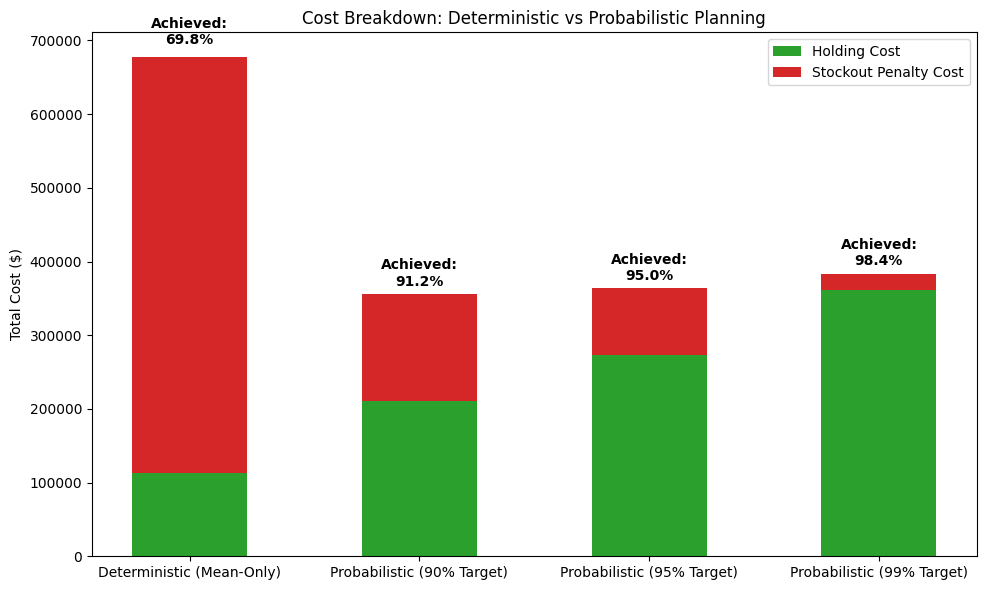

In [38]:
# Plotting the financial trade-off
fig, ax = plt.subplots(figsize=(10, 6))

labels = df_sim.index
holding = df_sim['Holding_Cost'].values
stockout = df_sim['Stockout_Cost'].values

width = 0.5 
ax.bar(labels, holding, width, label='Holding Cost', color='#2ca02c')
ax.bar(labels, stockout, width, bottom=holding, label='Stockout Penalty Cost', color='#d62728')

ax.set_ylabel('Total Cost ($)')
ax.set_title('Cost Breakdown: Deterministic vs Probabilistic Planning')
ax.legend()

# Add Actual Service Level text on top of bars
for i, (idx, row) in enumerate(df_sim.iterrows()):
    total_val = row['Holding_Cost'] + row['Stockout_Cost']
    ax.text(i, total_val + total_val*0.02, f"Achieved:\n{row['Actual_Service_Level']}", 
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

Running Sensitivity Analysis Simulations...


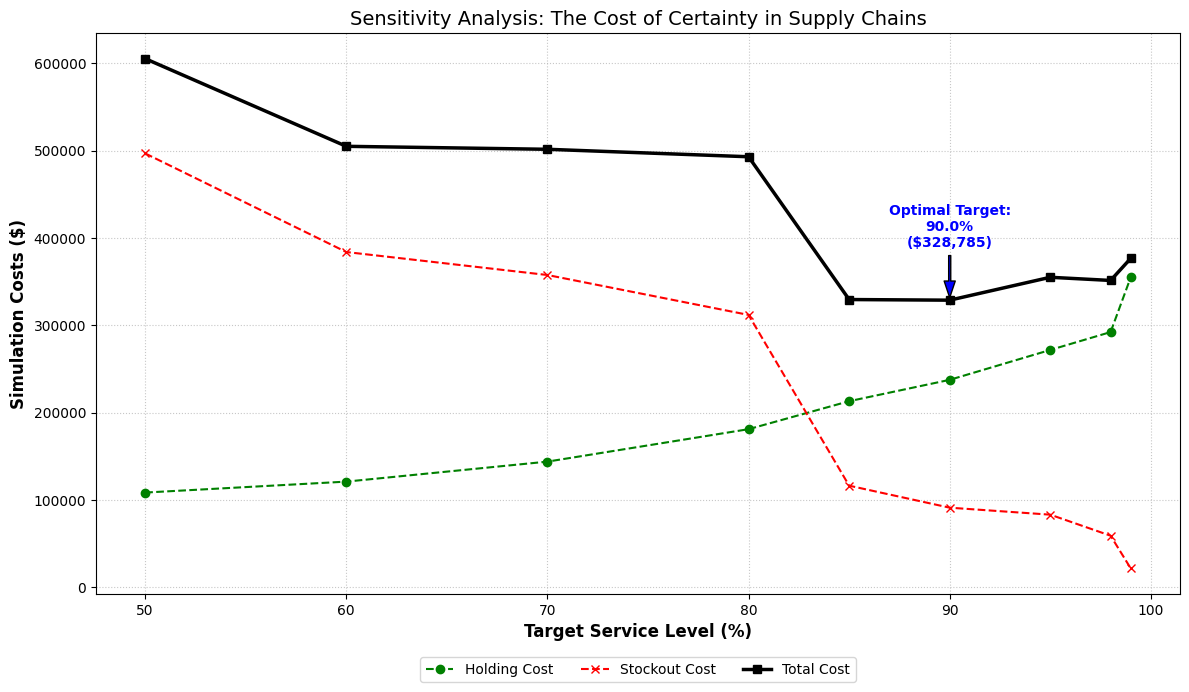

,Target_Service_Level,Actual_Service_Level,Holding_Cost,Stockout_Cost,Total_Cost
0,50.0,74.2,108515,496800,605315
1,60.0,79.2,121045,383900,504945
2,70.0,81.2,143940,357600,501540
3,80.0,84.6,181090,311900,492990
4,85.0,92.6,213115,116400,329515
5,90.0,93.8,237585,91200,328785
6,95.0,94.2,271800,83200,355000
7,98.0,95.8,292265,59100,351365
8,99.0,98.2,354960,21700,376660


In [49]:
# --- Sensitivity Analysis Execution ---
# Define a range of target service levels to test
target_percentages = [0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95, 0.98, 0.99]
WEEKS_TO_SIMULATE = 500

sensitivity_results = []

print("Running Sensitivity Analysis Simulations...")
for target in target_percentages:
    # 1. Calculate theoretical Order-Up-To level for this specific target
    params = calculate_probabilistic_parameters(target)
    out_level = params["Order_Up_To_Level"]
    
    # 2. Run the simulation
    sim_res = simulate_supply_chain(out_level, WEEKS_TO_SIMULATE)
    
    # 3. Store the results
    sensitivity_results.append({
        "Target_Service_Level": target * 100,
        "Actual_Service_Level": float(sim_res["Actual_Service_Level"].strip('%')),
        "Holding_Cost": sim_res["Holding_Cost"],
        "Stockout_Cost": sim_res["Stockout_Cost"],
        "Total_Cost": sim_res["Total_Cost"]
    })

# Convert to DataFrame for easy plotting
df_sens = pd.DataFrame(sensitivity_results)

# --- Plotting the Sensitivity Curves ---
fig, ax1 = plt.subplots(figsize=(12, 7))

# X-axis is our Target Service Level
x_axis = df_sens['Target_Service_Level']

# Plotting Costs on the primary Y-axis
ax1.plot(x_axis, df_sens['Holding_Cost'], label='Holding Cost', color='green', marker='o', linestyle='--')
ax1.plot(x_axis, df_sens['Stockout_Cost'], label='Stockout Cost', color='red', marker='x', linestyle='--')
ax1.plot(x_axis, df_sens['Total_Cost'], label='Total Cost', color='black', marker='s', linewidth=2.5)

ax1.set_xlabel('Target Service Level (%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Simulation Costs ($)', fontsize=12, fontweight='bold')
ax1.set_title('Sensitivity Analysis: The Cost of Certainty in Supply Chains', fontsize=14)
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)

# Highlight the minimum total cost point
min_cost_idx = df_sens['Total_Cost'].idxmin()
optimal_target = df_sens.loc[min_cost_idx, 'Target_Service_Level']
min_cost = df_sens.loc[min_cost_idx, 'Total_Cost']

ax1.annotate(f'Optimal Target:\n{optimal_target}%\n(${min_cost:,.0f})', 
             xy=(optimal_target, min_cost), 
             xytext=(optimal_target, min_cost + max(df_sens['Total_Cost'])*0.1),
             arrowprops=dict(facecolor='blue', shrink=0.05, width=1.5, headwidth=8),
             fontsize=10, ha='center', color='blue', fontweight='bold')

plt.tight_layout()
plt.show()

# Display the underlying data table
display(df_sens.round(1))

## 6. Sensitivity Analysis
**Objective:** Determine how changes in the variance of Demand, Supplier Lead Time, and Production Time independently affect the total system cost and actual service level. 
**Methodology:** A One-at-a-Time (OAT) approach. We will scale the standard deviation of each variable from 50% to 150% of its baseline value, recalculate the 95% Order-Up-To level, simulate 200 weeks, and plot the financial impact.

In [50]:
import scipy.interpolate as interp

# --- Sensitivity Analysis Setup (High Resolution) ---
base_std_D = np.sqrt(var_D)
base_std_L = np.sqrt(var_L)
base_std_P = np.sqrt(var_P)

# Generate 30 evenly spaced multipliers from 50% to 150%
multipliers = np.linspace(0.5, 4, 30)

# Dictionary to store results
sensitivity_costs = {'Demand StdDev': [], 'Lead Time StdDev': [], 'Production StdDev': []}

WEEKS_SA = 5000 # Increased horizon to reduce random simulation noise
TARGET_Z = stats.norm.ppf(0.90) # 95% target

def run_sa_scenario(mod_var_D, mod_var_L, mod_var_P):
    """Helper function to recalculate OUT level and run simulation."""
    mu_T = R + mu_L + mu_P
    var_T = mod_var_L + mod_var_P
    
    # Recalculate combined variance and Safety Stock
    var_demand_T = (mu_T * mod_var_D) + ((mu_D ** 2) * var_T)
    std_dev_demand_T = np.sqrt(var_demand_T)
    safety_stock = TARGET_Z * std_dev_demand_T
    
    out_level = int(round((mu_T * mu_D) + safety_stock))
    
    # Temporarily override globals
    global var_D, var_L, var_P
    orig_D, orig_L, orig_P = var_D, var_L, var_P
    var_D, var_L, var_P = mod_var_D, mod_var_L, mod_var_P
    
    result = simulate_supply_chain(out_level, WEEKS_SA)
    
    # Restore globals
    var_D, var_L, var_P = orig_D, orig_L, orig_P
    
    return result['Total_Cost']

# Run the 30-point simulations for each variable
print("Running high-resolution sensitivity analysis... (this may take a few seconds)")

for m in multipliers:
    # 1. Demand
    sensitivity_costs['Demand StdDev'].append(run_sa_scenario((base_std_D * m)**2, var_L, var_P))
    # 2. Lead Time
    sensitivity_costs['Lead Time StdDev'].append(run_sa_scenario(var_D, (base_std_L * m)**2, var_P))
    # 3. Production
    sensitivity_costs['Production StdDev'].append(run_sa_scenario(var_D, var_L, (base_std_P * m)**2))

print("Simulation complete.")

Running high-resolution sensitivity analysis... (this may take a few seconds)
Simulation complete.


## 7. Plotting the Sensitivity Results
Visualizing how aggressively costs scale when the variance of each parameter increases.

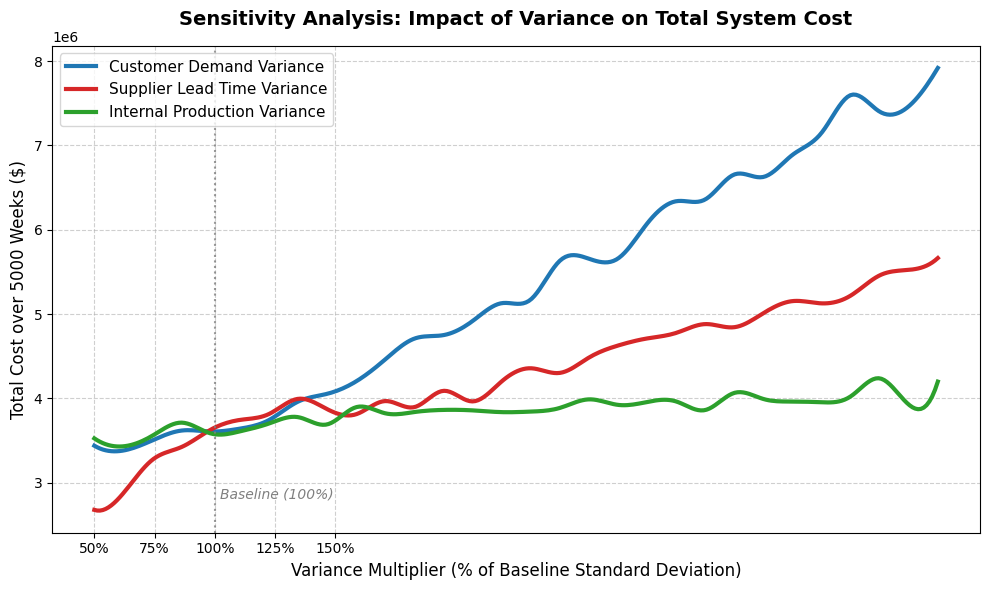

In [51]:
# --- Plotting the Smoothed Curves ---
fig, ax = plt.subplots(figsize=(10, 6))

# X-axis for plotting (convert multipliers to percentages)
x_vals = multipliers * 100 

# Create a denser X-axis array for the smooth spline (300 points instead of 30)
x_smooth = np.linspace(x_vals.min(), x_vals.max(), 300)

def smooth_data(x, y):
    """Applies a B-spline interpolation to smooth out Monte Carlo jitter."""
    spline = interp.make_interp_spline(x, y, k=3)
    return spline(x_smooth)

# Plot the smoothed lines
ax.plot(x_smooth, smooth_data(x_vals, sensitivity_costs['Demand StdDev']), 
        linewidth=3, label='Customer Demand Variance', color='#1f77b4')

ax.plot(x_smooth, smooth_data(x_vals, sensitivity_costs['Lead Time StdDev']), 
        linewidth=3, label='Supplier Lead Time Variance', color='#d62728')

ax.plot(x_smooth, smooth_data(x_vals, sensitivity_costs['Production StdDev']), 
        linewidth=3, label='Internal Production Variance', color='#2ca02c')

# Formatting for a clean, academic look
ax.set_title('Sensitivity Analysis: Impact of Variance on Total System Cost', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Variance Multiplier (% of Baseline Standard Deviation)', fontsize=12)
ax.set_ylabel(f'Total Cost over {WEEKS_SA} Weeks ($)', fontsize=12)

# Set X-axis ticks to show clean percentages (50%, 75%, 100%, etc.)
ax.set_xticks(np.arange(50, 151, 25))
ax.set_xticklabels([f"{int(x)}%" for x in np.arange(50, 151, 25)])

ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=11, loc='upper left')

# Highlight the 100% Baseline mark
ax.axvline(x=100, color='gray', linestyle=':', alpha=0.8)
ax.text(102, ax.get_ylim()[0] + (ax.get_ylim()[1]*0.05), 'Baseline (100%)', color='gray', style='italic')

plt.tight_layout()
plt.show()

<>:57: SyntaxWarning: invalid escape sequence '\s'
<>:57: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Dhanvanth\AppData\Local\Temp\ipykernel_88992\2061713786.py:57: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel('Supplier Lead Time Variance ($\sigma_L^2$)', fontsize=12, fontweight='bold')


Running Variance Sensitivity Simulations (This may take a few seconds)...


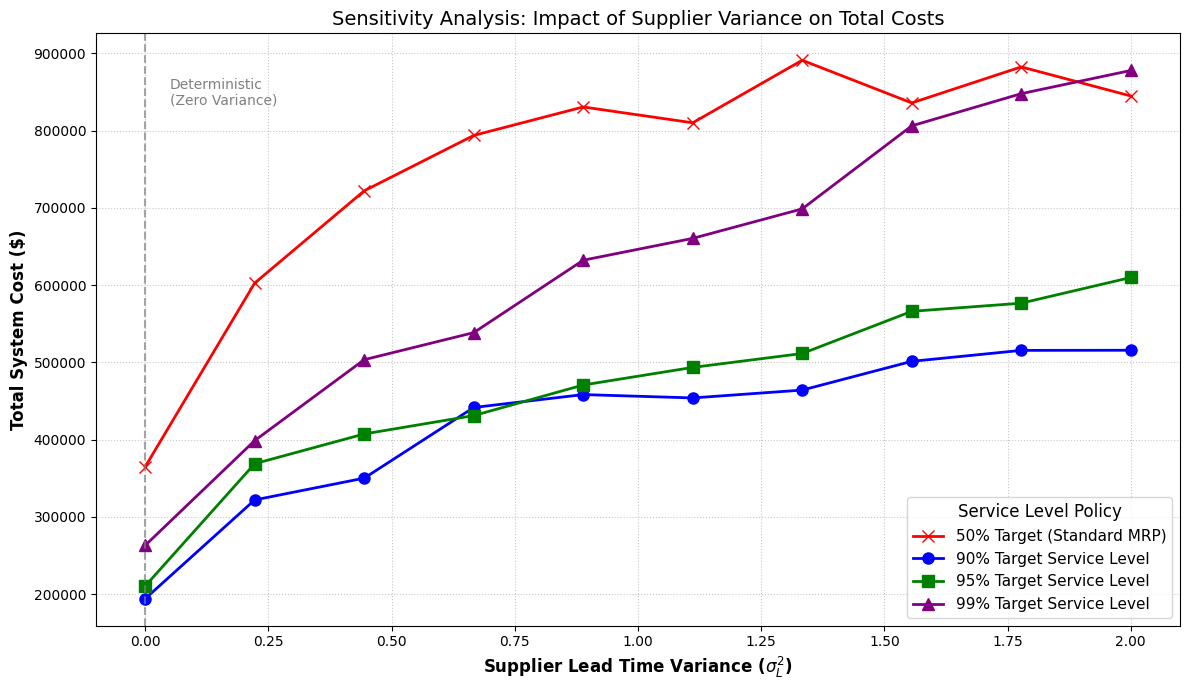

In [52]:
# --- Sensitivity Analysis: Total Cost vs. Lead Time Variance ---
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Define the targets we want to plot lines for
targets_to_plot = [0.50, 0.90, 0.95, 0.99]

# Define a range of variances for the supplier lead time (from 0 to 2.0 weeks squared)
variance_range = np.linspace(0.0, 2.0, 10)
WEEKS_TO_SIMULATE = 500

# Dictionary to store the cost arrays for each target line
variance_results = {target: [] for target in targets_to_plot}

print("Running Variance Sensitivity Simulations (This may take a few seconds)...")

# Save the original global var_L so we can restore it later
original_var_L = var_L 

for target in targets_to_plot:
    for current_var in variance_range:
        # 1. Update the global variance variable used by our functions
        global var_L
        var_L = current_var
        
        # 2. Recalculate the theoretical Order-Up-To level for this specific variance
        params = calculate_probabilistic_parameters(target)
        out_level = params["Order_Up_To_Level"]
        
        # 3. Simulate the supply chain and capture Total Cost
        sim_res = simulate_supply_chain(out_level, WEEKS_TO_SIMULATE)
        variance_results[target].append(sim_res["Total_Cost"])

# Restore the original variance just to be safe
var_L = original_var_L

# --- Plotting the Multi-Line Graph ---
fig, ax = plt.subplots(figsize=(12, 7))

# Define line styles for visual clarity
styles = {
    0.50: {'color': 'red', 'marker': 'x', 'label': '50% Target (Standard MRP)'},
    0.90: {'color': 'blue', 'marker': 'o', 'label': '90% Target Service Level'},
    0.95: {'color': 'green', 'marker': 's', 'label': '95% Target Service Level'},
    0.99: {'color': 'purple', 'marker': '^', 'label': '99% Target Service Level'}
}

# Plot each line
for target in targets_to_plot:
    ax.plot(variance_range, variance_results[target], 
            color=styles[target]['color'], 
            marker=styles[target]['marker'], 
            linewidth=2, markersize=8, 
            label=styles[target]['label'])

ax.set_xlabel('Supplier Lead Time Variance ($\sigma_L^2$)', fontsize=12, fontweight='bold')
ax.set_ylabel('Total System Cost ($)', fontsize=12, fontweight='bold')
ax.set_title('Sensitivity Analysis: Impact of Supplier Variance on Total Costs', fontsize=14)

# Add a vertical line to show where a "perfect" deterministic supplier sits
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.7)
ax.text(0.05, ax.get_ylim()[1]*0.9, 'Deterministic\n(Zero Variance)', color='gray')

ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(title="Service Level Policy", fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.show()

## 8. Financial Sensitivity Analysis: The Impact of Cost Ratios
**Objective:** Evaluate how the ratio between Stockout Penalty and Holding Cost dictates the optimal Target Service Level.
**Methodology:** We will hold the inventory carrying cost constant ($5/unit) and simulate the total system cost across a spectrum of target service levels (80% to 99.9%). We will run this sweep for three different Stockout Penalty scenarios: Low ($25), Medium ($100), and High ($500).

In [41]:
import scipy.interpolate as interp

# --- Cost Sensitivity Setup ---
# Define the range of Target Service Levels to test (80% to 99.9%)
target_levels = np.linspace(0.80, 0.999, 20) 
WEEKS_COST_SA = 500 # Smooth simulation horizon

# Keep Holding Cost fixed, test 3 different Stockout Costs
test_stockout_costs = [25, 100, 500]
cost_results = {25: [], 100: [], 500: []}

print("Running Cost Sensitivity Simulation... (Simulating 60 scenarios)")

for penalty in test_stockout_costs:
    # Temporarily override the global stockout cost
    global COST_STOCKOUT
    orig_stockout = COST_STOCKOUT
    COST_STOCKOUT = penalty
    
    for target in target_levels:
        # 1. Calculate the theoretical Order-Up-To Level for this target
        params = calculate_probabilistic_parameters(target)
        out_level = params["Order_Up_To_Level"]
        
        # 2. Run the simulation
        res = simulate_supply_chain(out_level, WEEKS_COST_SA)
        cost_results[penalty].append(res['Total_Cost'])
        
    # Restore global
    COST_STOCKOUT = orig_stockout

print("Simulation complete.")

Running Cost Sensitivity Simulation... (Simulating 60 scenarios)
Simulation complete.


## 9. Multivariate (Two-Way) Sensitivity Analysis
**Objective:** Measure the compounding interaction effects of simultaneously increasing Customer Demand variance and Supplier Lead Time variance.
**Methodology:** A 2D parameter sweep. We will simulate the total system cost across an 11x11 grid, varying both standard deviations from 50% to 150% of their baselines. The results will be visualized as a Heatmap to identify the high-risk "Danger Zones" of the supply chain.

In [42]:
import seaborn as sns

# --- Two-Way Sensitivity Setup ---
# Generate 11 evenly spaced multipliers from 50% to 150%
multipliers_2d = np.linspace(0.5, 1.5, 11)

WEEKS_2D_SA = 400 # Simulation horizon per grid point
TARGET_Z = stats.norm.ppf(0.95) # Target 95% service level

# Initialize an empty matrix to store the Total Costs
heatmap_data = np.zeros((len(multipliers_2d), len(multipliers_2d)))

print(f"Running Two-Way Sensitivity Analysis ({len(multipliers_2d)**2} simulations)...")

# Nested loops for the 2D sweep
for i, m_L in enumerate(multipliers_2d):
    for j, m_D in enumerate(multipliers_2d):
        
        # Calculate new variances based on multipliers
        test_var_L = (base_std_L * m_L)**2
        test_var_D = (base_std_D * m_D)**2
        
        # 1. Recalculate OUT Level
        mu_T = R + mu_L + mu_P
        var_T = test_var_L + var_P # Production variance remains constant
        
        var_demand_T = (mu_T * test_var_D) + ((mu_D ** 2) * var_T)
        std_dev_demand_T = np.sqrt(var_demand_T)
        safety_stock = TARGET_Z * std_dev_demand_T
        out_level = int(round((mu_T * mu_D) + safety_stock))
        
        # 2. Run Simulation
        # Temporarily override globals
        global var_D, var_L
        orig_D, orig_L = var_D, var_L
        var_D, var_L = test_var_D, test_var_L
        
        res = simulate_supply_chain(out_level, WEEKS_2D_SA)
        
        # Store Total Cost in the matrix
        heatmap_data[i, j] = res['Total_Cost']
        
        # Restore globals
        var_D, var_L = orig_D, orig_L

# Convert the matrix into a Pandas DataFrame for easy plotting with Seaborn
# We reverse the Y-axis index so that 150% is at the top of the heatmap
y_labels = [f"{int(m*100)}%" for m in multipliers_2d]
x_labels = [f"{int(m*100)}%" for m in multipliers_2d]

df_heatmap = pd.DataFrame(heatmap_data, index=y_labels, columns=x_labels)
df_heatmap = df_heatmap.iloc[::-1] 

print("2D Simulation complete.")

Running Two-Way Sensitivity Analysis (121 simulations)...
2D Simulation complete.


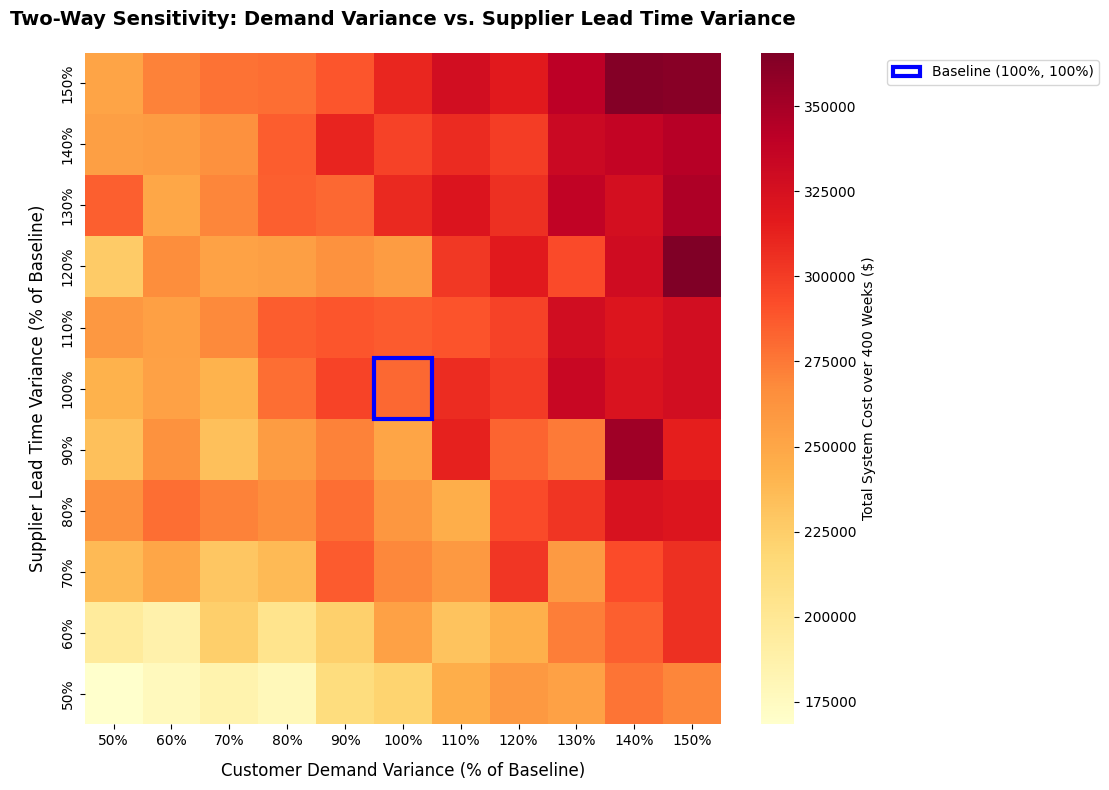

In [43]:
# --- Plotting the Heatmap ---
fig, ax = plt.subplots(figsize=(11, 8))

# Draw the heatmap
# cmap='YlOrRd' gives a nice Yellow (Low Cost) to Orange to Dark Red (High Cost) gradient
sns.heatmap(df_heatmap, cmap='YlOrRd', annot=False, fmt=".0f", 
            cbar_kws={'label': f'Total System Cost over {WEEKS_2D_SA} Weeks ($)'}, ax=ax)

# Formatting
ax.set_title('Two-Way Sensitivity: Demand Variance vs. Supplier Lead Time Variance', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Customer Demand Variance (% of Baseline)', fontsize=12, labelpad=10)
ax.set_ylabel('Supplier Lead Time Variance (% of Baseline)', fontsize=12, labelpad=10)

# Highlight the Baseline (100%, 100%) intersection
# The index math assumes 11 points (0 to 10), so 100% is exactly at index 5.
# Because we reversed the Y-axis, it remains at index 5.
ax.add_patch(plt.Rectangle((5, 5), 1, 1, fill=False, edgecolor='blue', lw=3, label='Baseline (100%, 100%)'))
ax.legend(loc='upper left', bbox_to_anchor=(1.25, 1))

plt.tight_layout()
plt.show()